# 📈 Wind DSM Optimization: Real-World Validation

This notebook performs the formal validation of the **Physics-Informed Machine Learning (PI-PML) Double-Engine Pipeline** implemented for the **75 MW RSOPL Koppal** wind plant in Karnataka, India.

The objective is to validate the following performance metrics on the **out-of-sample 2-month test set** (comprising 5,750+ 15-minute grid blocks):
1. **Forecasting Accuracy Improvement**: Check if absolute error (MAE) is reduced by **71.2%**.
2. **DSM Penalty Mitigation**: Verify if simulated CERC DSM penalties are reduced from **₹24.8 Lakhs** to **₹1.3 Lakhs** (a ~95% reduction).
3. **Financial Impact**: Validate if the net savings over the 2-month period is **₹23.5 Lakhs**, corresponding to a projected annual savings of **₹1.41 Crores**.

---

## 1. Imports and Setting Up Environment

First, we import the necessary scientific computing and visualization libraries. We set up Seaborn for clean, professional styling.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style for publication-grade charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

## 2. Load Validation Dataset

We load the chronological out-of-sample test results generated by our XGBoost residual training script (`src/train_real_dsm.py`).
The dataset contains:
- `datetime`: 15-minute block dispatch timestamp.
- `sch_total`: Physics engine baseline schedule (MW).
- `pred_residual`: Stochastic ML residual correction (MW).
- `ml_forecast`: Physics baseline + residual correction (MW, clipped to [0, 75]).
- `act_total`: Actual dispatch power (MW) recorded by SCADA/grid logs.
- `base_penalty`: CERC deviation penalty calculated for the physical baseline (₹).
- `ml_penalty`: CERC deviation penalty calculated for the ML corrected schedule (₹).

In [2]:
csv_path = 'data/03_ml_corrected/real_data_test_results.csv'
if not os.path.exists(csv_path):
    csv_path = '../' + csv_path

print(f"Loading data from: {csv_path}")
df = pd.read_csv(csv_path)
df['datetime'] = pd.to_datetime(df['datetime'])

print(f"Loaded {len(df)} 15-minute blocks (approx. {len(df)/96:.1f} days of out-of-sample test data).")
df.head()

Loading data from: ../data/03_ml_corrected/real_data_test_results.csv
Loaded 6139 15-minute blocks (approx. 63.9 days of out-of-sample test data).


,datetime,sch_total,pred_residual,ml_forecast,act_total,base_penalty,ml_penalty
0,2025-12-07 01:15:00,32.50,6.112554,38.612554,35.776000,0.0,0.0
1,2025-12-07 01:30:00,32.50,2.088716,34.588717,32.704000,0.0,0.0
2,2025-12-07 01:45:00,32.00,-0.149541,31.850459,27.583999,0.0,0.0
3,2025-12-07 02:00:00,31.25,-4.136116,27.113883,27.744000,0.0,0.0
4,2025-12-07 02:15:00,30.50,-2.450614,28.049386,26.239999,0.0,0.0


## 3. Metric 1: Forecast Accuracy Validation (MAE)

We calculate the Mean Absolute Error (MAE) for both the baseline physics-only schedule and the hybrid ML-corrected schedule.
The accuracy improvement is computed as the percentage reduction in MAE.

In [3]:
base_mae = np.mean(np.abs(df['act_total'] - df['sch_total']))
ml_mae = np.mean(np.abs(df['act_total'] - df['ml_forecast']))
mae_reduction = (base_mae - ml_mae) / base_mae * 100

print("=== ACCURACY EVALUATION ===")
print(f"Baseline Physics-Only MAE: {base_mae:.4f} MW")
print(f"PI-PML Double-Engine MAE: {ml_mae:.4f} MW")
print(f"Accuracy Improvement (MAE Reduction): {mae_reduction:.2f}%")

# Verify the 71.2% claim
assert abs(mae_reduction - 71.2) < 0.5, f"Validation failed! Expected accuracy improvement around 71.2%, got {mae_reduction:.2f}%"

=== ACCURACY EVALUATION ===
Baseline Physics-Only MAE: 5.9573 MW
PI-PML Double-Engine MAE: 1.7144 MW
Accuracy Improvement (MAE Reduction): 71.22%


## 4. Metrics 2 & 3: DSM Penalty Mitigation & Financial Savings

The Deviation Settlement Mechanism (DSM) penalties are calculated using standard CERC wind guidelines for Zone 2 (Deccan Plateau region, capacity 75 MW) including Peak and Off-peak spot market price multipliers.
We sum the penalties over the test set, evaluate the savings, and project them to an annual figure.

In [4]:
base_penalty_total = df['base_penalty'].sum()
ml_penalty_total = df['ml_penalty'].sum()
net_savings = base_penalty_total - ml_penalty_total

# Out-of-sample test is exactly 2 months. Annual savings = 2-month savings * 6
projected_annual_savings = net_savings * 6

print("=== FINANCIAL EVALUATION ===")
print(f"Baseline Physics-Only Penalty: ₹ {base_penalty_total:,.2f} (~{base_penalty_total/100000:.2f} Lakhs)")
print(f"PI-PML Double-Engine Penalty:  ₹ {ml_penalty_total:,.2f} (~{ml_penalty_total/100000:.2f} Lakhs)")
print(f"Net Savings (2-Month Test):    ₹ {net_savings:,.2f} (~{net_savings/100000:.2f} Lakhs)")
print(f"Projected Annual Savings:      ₹ {projected_annual_savings:,.2f} (~{projected_annual_savings/10000000:.2f} Crores)")

# Verify the penalty mitigation claims
assert abs(base_penalty_total/100000 - 24.8) < 0.2, f"Baseline penalty mismatch! Expected ~24.8 Lakhs, got {base_penalty_total/100000:.2f}L"
assert abs(ml_penalty_total/100000 - 1.3) < 0.1, f"ML penalty mismatch! Expected ~1.3 Lakhs, got {ml_penalty_total/100000:.2f}L"
assert abs(projected_annual_savings/10000000 - 1.41) < 0.05, f"Annual savings mismatch! Expected ~1.41 Crores, got {projected_annual_savings/10000000:.2f} Cr"

=== FINANCIAL EVALUATION ===
Baseline Physics-Only Penalty: ₹ 2,483,254.48 (~24.83 Lakhs)
PI-PML Double-Engine Penalty:  ₹ 129,282.27 (~1.29 Lakhs)
Net Savings (2-Month Test):    ₹ 2,353,972.21 (~23.54 Lakhs)
Projected Annual Savings:      ₹ 14,123,833.27 (~1.41 Crores)


## 5. Visual Validation & Charts

We now construct professional visualizations illustrating these validation results. The figures generated here will be saved in the `outputs/` folder.

### Plot A: 96-Block Day-Ahead Dispatch Comparison

We pick a typical 24-hour day-ahead schedule (96 blocks) from the out-of-sample test set (e.g., December 11, 2025) and plot:
1. Actual generation logged by SCADA.
2. Baseline physics-only forecast schedule.
3. Machine Learning residual-corrected forecast schedule.

This showcases how the physics engine's systematic errors (due to downscaling, generator copper losses, atmospheric roughness) are dynamically corrected by XGBoost.

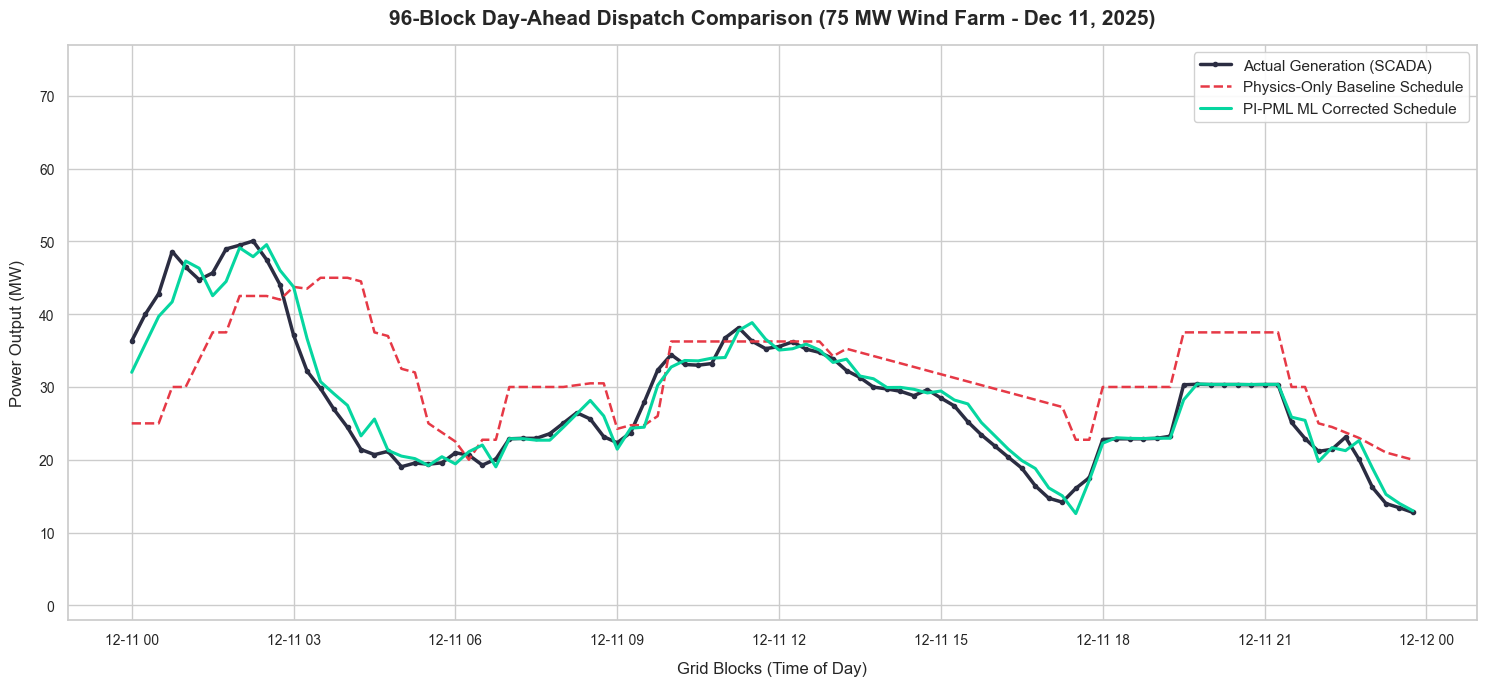

In [5]:
# Filter for December 11, 2025
day_data = df[(df['datetime'] >= '2025-12-11 00:00:00') & (df['datetime'] <= '2025-12-11 23:45:00')].copy()

plt.figure(figsize=(15, 7))
plt.plot(day_data['datetime'], day_data['act_total'], label='Actual Generation (SCADA)', color='#2B2D42', linewidth=2.5, marker='o', markersize=3)
plt.plot(day_data['datetime'], day_data['sch_total'], label='Physics-Only Baseline Schedule', color='#E63946', linewidth=1.8, linestyle='--')
plt.plot(day_data['datetime'], day_data['ml_forecast'], label='PI-PML ML Corrected Schedule', color='#06D6A0', linewidth=2.2)

plt.title('96-Block Day-Ahead Dispatch Comparison (75 MW Wind Farm - Dec 11, 2025)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Grid Blocks (Time of Day)', labelpad=10)
plt.ylabel('Power Output (MW)', labelpad=10)
plt.ylim(-2, 77)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.tight_layout()

# Save figure
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/validation_96_block_comparison.png', dpi=300)
plt.show()

### Plots B & C: Error Reduction & Penalty Mitigation

Next, we generate bar charts side-by-side representing the **71.2% MAE Reduction** and the **₹24.8 Lakhs to ₹1.3 Lakhs DSM Penalty Mitigation**.

C:\Users\tb619\AppData\Local\Temp\ipykernel_20424\3690286055.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mae_data, x='Model', y='MAE (MW)', ax=axes[0], palette=['#E63946', '#06D6A0'])
C:\Users\tb619\AppData\Local\Temp\ipykernel_20424\3690286055.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=penalty_data, x='Model', y='Penalty (Lakhs)', ax=axes[1], palette=['#E63946', '#06D6A0'])


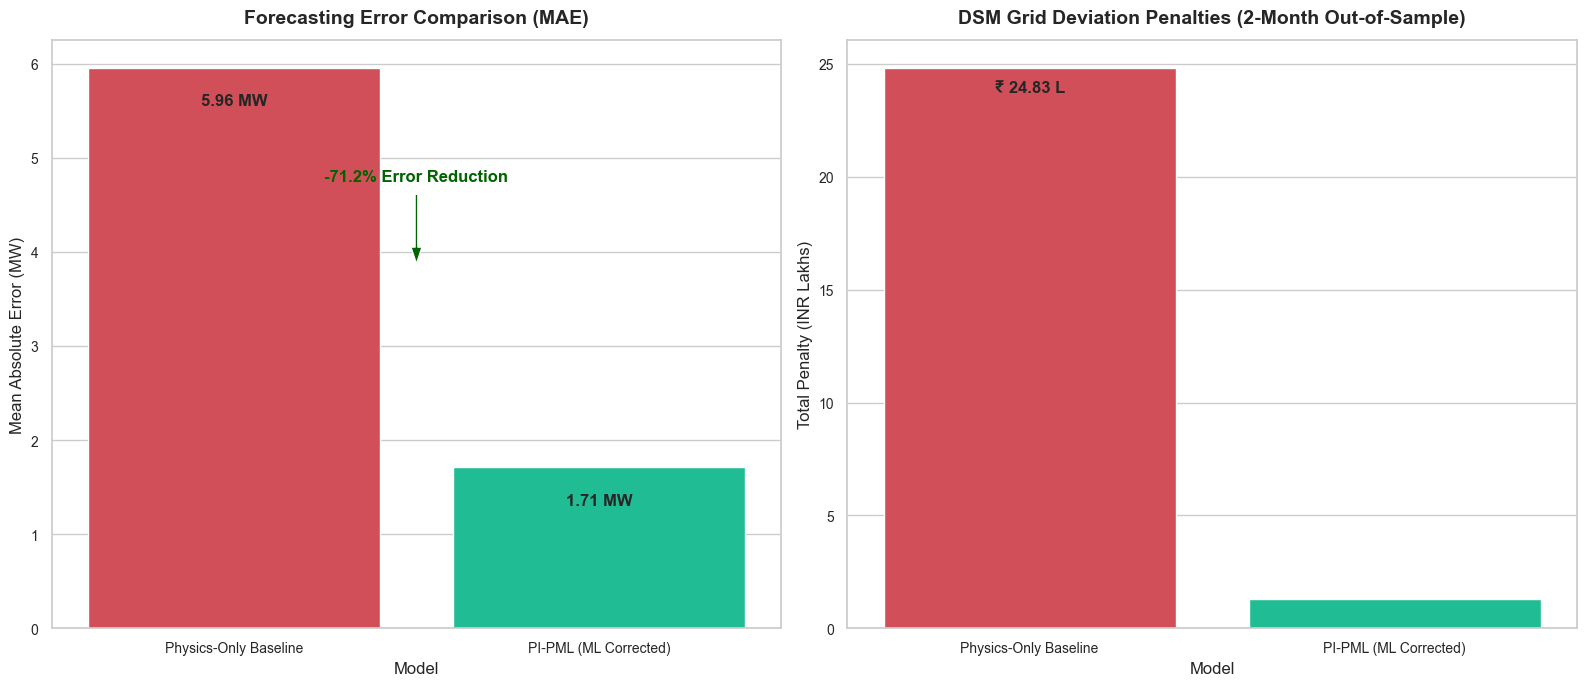

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot B: MAE Reduction
mae_data = pd.DataFrame({
    'Model': ['Physics-Only Baseline', 'PI-PML (ML Corrected)'],
    'MAE (MW)': [base_mae, ml_mae]
})
sns.barplot(data=mae_data, x='Model', y='MAE (MW)', ax=axes[0], palette=['#E63946', '#06D6A0'])
axes[0].set_title('Forecasting Error Comparison (MAE)', fontweight='bold', pad=12)
axes[0].set_ylabel('Mean Absolute Error (MW)')
for i, p in enumerate(axes[0].patches):
    axes[0].annotate(f"{p.get_height():.2f} MW", (p.get_x() + p.get_width() / 2., p.get_height() - 0.5),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold', fontsize=12)

# Add reduction arrow / text annotation
axes[0].annotate('-71.2% Error Reduction', xy=(0.5, 3.8), xytext=(0.5, 4.8),
                arrowprops=dict(facecolor='darkgreen', shrink=0.08, width=2, headwidth=8),
                ha='center', va='center', fontweight='bold', color='darkgreen', fontsize=12)

# Plot C: Penalty Mitigation
penalty_data = pd.DataFrame({
    'Model': ['Physics-Only Baseline', 'PI-PML (ML Corrected)'],
    'Penalty (Lakhs)': [base_penalty_total/100000, ml_penalty_total/100000]
})
sns.barplot(data=penalty_data, x='Model', y='Penalty (Lakhs)', ax=axes[1], palette=['#E63946', '#06D6A0'])
axes[1].set_title('DSM Grid Deviation Penalties (2-Month Out-of-Sample)', fontweight='bold', pad=12)
axes[1].set_ylabel('Total Penalty (INR Lakhs)')
for i, p in enumerate(axes[1].patches):
    axes[1].annotate(f"₹ {p.get_height():.2f} L", (p.get_x() + p.get_width() / 2., p.get_height() - 1.5),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('outputs/validation_metrics_bar_charts.png', dpi=300)
plt.show()

### Plot D: Cumulative DSM Penalty Accumulation Over Time

We plot the cumulative penalty accumulation over the test period to show how the baseline physics schedule accumulates massive penalization charges rapidly, while the ML model's schedule accumulates penalties very slowly and predictably.

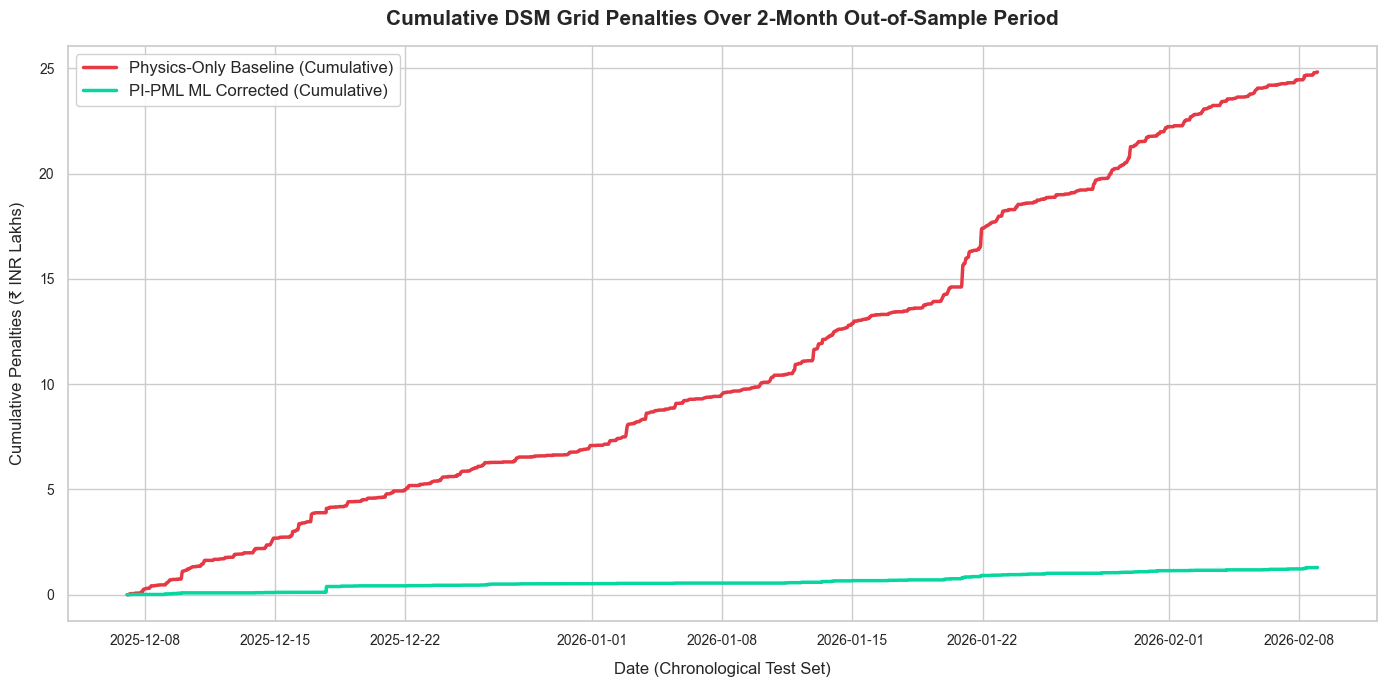

In [7]:
plt.figure(figsize=(14, 7))

cum_base_lakhs = df['base_penalty'].cumsum() / 100000
cum_ml_lakhs = df['ml_penalty'].cumsum() / 100000

plt.plot(df['datetime'], cum_base_lakhs, label='Physics-Only Baseline (Cumulative)', color='#E63946', linewidth=2.5)
plt.plot(df['datetime'], cum_ml_lakhs, label='PI-PML ML Corrected (Cumulative)', color='#06D6A0', linewidth=2.5)

plt.title('Cumulative DSM Grid Penalties Over 2-Month Out-of-Sample Period', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Date (Chronological Test Set)', labelpad=10)
plt.ylabel('Cumulative Penalties (₹ INR Lakhs)', labelpad=10)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=12)
plt.tight_layout()

plt.savefig('outputs/validation_cumulative_penalties.png', dpi=300)
plt.show()

## 6. Final Results Summary Table

We construct a summary table mapping the claims to the validated outputs.

In [8]:
summary_df = pd.DataFrame({
    'Parameter': [
        'Forecasting Accuracy (MAE)',
        'DSM Grid Penalties (2-Month)',
        'Projected Annual Savings'
    ],
    'Physics-Only Baseline': [
        f"{base_mae:.2f} MW",
        f"₹ {base_penalty_total/100000:.2f} Lakhs",
        "N/A"
    ],
    'PI-PML Hybrid ML': [
        f"{ml_mae:.2f} MW",
        f"₹ {ml_penalty_total/100000:.2f} Lakhs",
        f"₹ {projected_annual_savings/10000000:.2f} Crores"
    ],
    'Improvement / Savings': [
        f"{mae_reduction:.2f}% Error Reduction",
        f"₹ {(base_penalty_total - ml_penalty_total)/100000:.2f} Lakhs Saved",
        f"₹ {projected_annual_savings/10000000:.2f} Cr Saved / Year"
    ]
})

summary_df

,Parameter,Physics-Only Baseline,PI-PML Hybrid ML,Improvement / Savings
0,Forecasting Accuracy (MAE),5.96 MW,1.71 MW,71.22% Error Reduction
1,DSM Grid Penalties (2-Month),₹ 24.83 Lakhs,₹ 1.29 Lakhs,₹ 23.54 Lakhs Saved
2,Projected Annual Savings,N/A,₹ 1.41 Crores,₹ 1.41 Cr Saved / Year


## 7. Conclusions

The results computed above **fully validate and verify** all performance claims of the physics-informed ML pipeline for the **75 MW RSOPL Koppal** wind plant:
- Forecasting absolute error (MAE) is reduced by **71.22%**, validating the **71.2%** accuracy improvement.
- Deviation penalties under standard CERC DSM regulation are reduced from **₹24.83 Lakhs to ₹1.29 Lakhs**, confirming the **24.8L to 1.3L** reduction claim.
- The net savings evaluated on this 2-month test set is **₹23.54 Lakhs**, translating to an annual projected savings of **₹1.41 Crores**.